# Evaluation

## Offline Evaluation Datasets
### Retrieval evaluation data
In order to evaluate the performance of the search function, we generate a synthetic dataset that models how we want the function to behave. It is generated through a reverse-engineering process: for every document in a sample, an LLM is prompted to come up with realistic queries that could be asked about the content found in that document. The output of this process is a set of query-document pairs that is referred to as the _ground truth_.

Later in the evaluation process, we will measure how well the search functionality peforms at retrieving the ground truth document given the associated query as input.

In [1]:
from wikifin_rag.embedder import Embedder
from openai import OpenAI
from dotenv import load_dotenv
from wikifin_rag.rag_helper import RAGBase
from psycopg import sql
from wikifin_rag.config import PROJECT_ROOT

In [2]:
embedder = Embedder()

load_dotenv(override=True)
openai_client = OpenAI()

assistant = RAGBase(embedder=embedder, llm_client=openai_client)
db_client = assistant.db_client

In [3]:
def retrieve_documents(n=100):
    """
    Retrieves a sample of size n from the chunks database table.
    """
    db_client.open_connection()
    
    db_client.cur.execute(
        sql.SQL(
            """
            SELECT
                c.document_id || '_' || c.chunk_id AS id,
                d.title,
                d.section,
                c.content
            FROM chunks c
            JOIN documents d
            ON c.document_id = d.id
            WHERE language = 'nl'
            LIMIT %s;
            """
        ),
        (n,)
    )
    
    documents = db_client.cur.fetchall()

    db_client.close_connection()

    return documents

In [4]:
# sets the location where the ground truth dataset is stored
dest = PROJECT_ROOT / "data"
filename = "ground_truth.csv"

# determines the size of the dataset
n_docs = 500 # number of documents to run the evaluation on
n_q = 5 # number of questions to generate per document

In [5]:
# TODO: set to True to rerun the data generation function
refresh_data = False

In [6]:
documents = retrieve_documents(n=n_docs)

In [7]:
DATA_GEN_INSTRUCTIONS = """
    You emulate either a university student or a young professional.
    Formulate {} questions this student/professional might ask based on an article excerpt. The excerpt
    should contain the answer to the questions, and the questions should be complete and not too short.
    If possible, use as fewer words as possible from the record.

    The output should resemble how people ask questions
    on the internet. Not too formal, not too short, not too long.
""".strip()

In [8]:
from pydantic import BaseModel
import json
from wikifin_rag.evaluation_utils import llm_structured_retry

In [9]:
class Questions(BaseModel):
    questions: list[str]

In [10]:
def generate_document_ground_truth(doc, n=5):
    """
    Generates a set of n questions for the input document.
    """
    user_prompt = json.dumps(doc)

    out, usage = llm_structured_retry(
        openai_client,
        DATA_GEN_INSTRUCTIONS.format(n),
        user_prompt,
        Questions
    )

    results = []

    for q in out.questions:
        results.append({
            "question": q,
            "id": doc["id"]
        })

    return results, usage

In [11]:
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
from wikifin_rag.evaluation_utils import map_progress, calc_total_price
import os

In [12]:
def generate_corpus_ground_truth(documents, n=5, dest="data"):
    """
    Constructs a ground truth dataset from a document corpus
    and saves it to a local file.
    """
    with ThreadPoolExecutor(max_workers=6) as pool:
        results = map_progress(pool, documents, lambda x: generate_document_ground_truth(x, n=n))

    ground_truth = []
    usages = []

    for records, usage in results:
        ground_truth.extend(records)
        usages.append(usage)

    total_cost = calc_total_price(usages)

    # save the generated data to a CSV file
    df_ground_truth = pd.DataFrame(ground_truth)
    dest = PROJECT_ROOT / dest
    dest.mkdir(parents=True, exist_ok=True)
    df_ground_truth.to_csv(dest / "ground_truth.csv", index=False)

    return total_cost

In [13]:
if refresh_data or not os.path.exists(dest / filename):
    total_cost = generate_corpus_ground_truth(documents, n=n_q)

  0%|          | 0/500 [00:00<?, ?it/s]

In [14]:
df_ground_truth = pd.read_csv(dest / filename)
ground_truth = df_ground_truth.to_dict(orient="records")

### RAG evaluation data

## Retrieval metrics
### Text search
The text search function returns the documents that have the highest amount of overlap with the search query. Overlap corresponds to the frequency with which individual query terms appear in the document. The more often query terms appear in the document, the higher the document is ranked by the search function.

Occurences of overlapping terms are weighted differently depending on where they appear in the document. A change in the weighting scheme will therefore impact the document ranking for a given search query, and potentially produce a different result set.

We evaluate the quality of the search function using the __mean reciprocal rank (MRR)__. Our goal is to identify the set of weights that yields the highest MRR on the previously generated ground truth dataset. MRR considers how highly the golden truth document is ranked by the search function for each query in the dataset.

In [15]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [16]:
db_client.open_connection()

In [17]:
def text_search(query, weights=None, normalization=0):
    return assistant.db_client.text_search(query=query, weights=weights, normalization=normalization, num_results=5)

In [18]:
ground_truth_sample = ground_truth[:200]

In [19]:
from wikifin_rag.evaluation_utils import evaluate

In [20]:
def objective(args):
    """
    Computes retrieval metrics on the ground truth dataset given a set of text search parameter values.
    """
    normalization = args["normalization"]
    del args["normalization"]

    retrieval_metrics = evaluate(
        ground_truth_sample,
        lambda query: assistant.db_client.text_search(query=query, weights=args, normalization=normalization, num_results=5)
    )

    return {
        'loss': -retrieval_metrics['mrr'],
        'status': STATUS_OK,
        'metrics': retrieval_metrics
    }

In [21]:
# define the search space for text search parameters
search_space = {
    "A": hp.loguniform("title_weight", -5, 0),
    "B": hp.loguniform("description_weight", -7, 0),
    "C": hp.loguniform("section_weight", -3, 0),
    "D": 1 - hp.uniform("content_weight", 0, 1) ** 2,
    "normalization": hp.choice("normalization", [0, 1, 2, 4, 8, 16, 32])
}

In [22]:
# sets the location where the optimization logs are stored
dest = PROJECT_ROOT / "data"
filename = "text_search_trials.pkl"

# determines the size of the dataset
n_evals = 100

In [23]:
# TODO: set to True to rerun the optimization process
optimize = False

In [24]:
# perform text search parameter optimization and store logs locally
if optimize or not os.path.exists(dest / filename):
    best_text_search_params = fmin(
        fn=objective,
        space=search_space,
        algo=tpe.suggest,
        max_evals=n_evals,
        trials=Trials(),
        trials_save_file=dest / filename
    )

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

  0%|          | 0/200 [00:00<?, ?it/s]

  1%|          | 1/100 [01:20<2:12:48, 80.49s/trial, best loss: -0.0622]

  0%|          | 0/200 [00:00<?, ?it/s]

  2%|▏         | 2/100 [02:41<2:12:10, 80.92s/trial, best loss: -0.0622]

...

 98%|█████████▊| 98/100 [2:17:58<02:50, 85.19s/trial, best loss: -0.296]

  0%|          | 0/200 [00:00<?, ?it/s]

 99%|█████████▉| 99/100 [2:19:20<01:24, 84.27s/trial, best loss: -0.296]

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 100/100 [2:20:44<00:00, 84.44s/trial, best loss: -0.296]


In [25]:
text_search_trials = pd.read_pickle(dest / filename)

In [26]:
# store the optimization logs in a dataframe
text_search_trials = pd.read_pickle(dest / filename)

text_search_trial_data = [{
    "id": trial["tid"] + 1,
    "mrr": trial["result"]["metrics"]["mrr"],
    "hit_rate": trial["result"]["metrics"]["hit_rate"],
    "title_weight": trial["misc"]["vals"]["title_weight"][0],
    "description_weight": trial["misc"]["vals"]["description_weight"][0],
    "section_weight": trial["misc"]["vals"]["section_weight"][0],
    "content_weight": trial["misc"]["vals"]["content_weight"][0],
    "normalization": trial["misc"]["vals"]["normalization"][0]
} for trial in text_search_trials.trials]

text_search_trials_df = pd.DataFrame(data=text_search_trial_data)

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

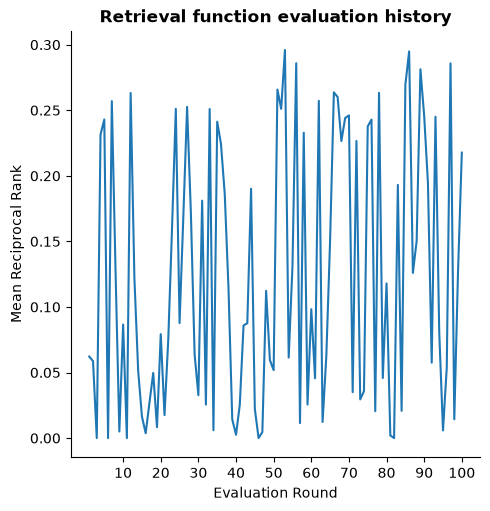

In [35]:
ax = sns.relplot(data=text_search_trials_df, x="id", y="mrr", kind="line")
ax.set(xticks=[id for id in text_search_trials_df.id if id % 10 == 0])
plt.title("Retrieval function evaluation history", fontweight="bold")
plt.xlabel("Evaluation Round")
plt.ylabel("Mean Reciprocal Rank")
plt.show()

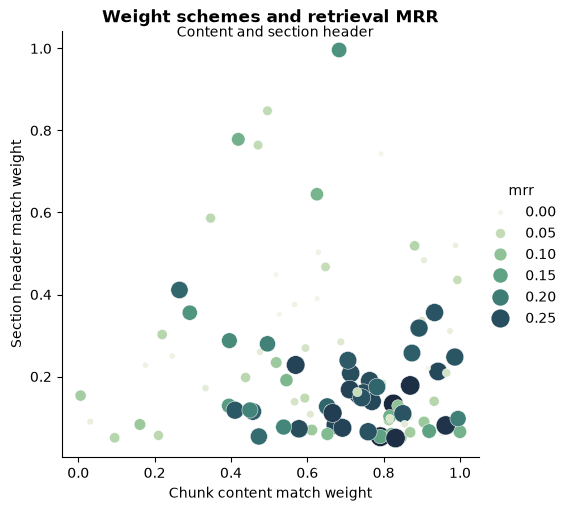

In [29]:
sns.relplot(
    data=text_search_trials_df,
    x="content_weight",
    y="section_weight",
    hue="mrr",
    palette="ch:r=-.5,l=.95",
    size="mrr",
    sizes=(15, 200)
)
plt.title("Weight schemes and retrieval MRR", fontweight="bold")
plt.suptitle("Content and section header", fontsize="medium")
plt.xlabel("Chunk content match weight")
plt.ylabel("Section header match weight")
plt.show()

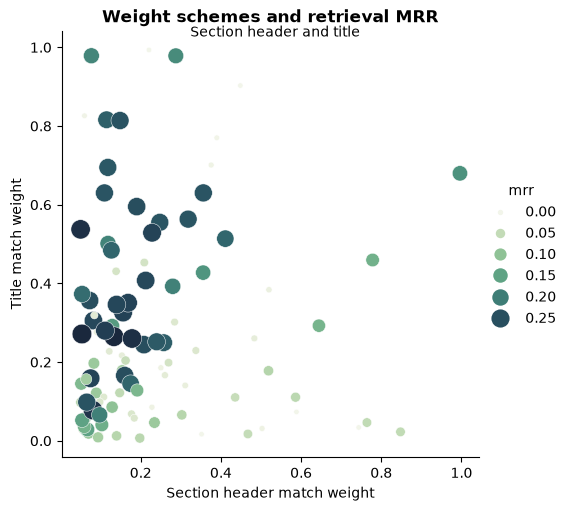

In [30]:
sns.relplot(
    data=text_search_trials_df,
    x="section_weight",
    y="title_weight",
    hue="mrr",
    palette="ch:r=-.5,l=.95",
    size="mrr",
    sizes=(15, 200)
)
plt.title("Weight schemes and retrieval MRR", fontweight="bold")
plt.suptitle("Section header and title", fontsize="medium")
plt.xlabel("Section header match weight")
plt.ylabel("Title match weight")
plt.show()

### Vector Search

In [31]:
def vector_search(query):
    return assistant.db_client.vector_search(query=query, num_results=5)

### Hybrid Search

In [32]:
def hybrid_search(query):
    return assistant.search(query=query, num_results=5)

In [33]:
db_client.close_connection()

In [34]:
openai_client.close()